## SCRIPT PROJET NLP SUR LA CLASSIFICATION DES ARTICLES(BUSINESS, TECH, SPORT, POLITICS, ENTERTAINMENT)

### Importation et exploration des données 

In [4]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [5]:
import pandas as pd

# Chargement de la table
data = pd.read_csv('bbc_news_text_complexity_summarization.csv')

# Aperçu des données
print(data.head())
print(data.info())

                                                text    labels  no_sentences  \
0  Ad sales boost Time Warner profit\n\nQuarterly...  business            26   
1  Dollar gains on Greenspan speech\n\nThe dollar...  business            17   
2  Yukos unit buyer faces loan claim\n\nThe owner...  business            14   
3  High fuel prices hit BA's profits\n\nBritish A...  business            24   
4  Pernod takeover talk lifts Domecq\n\nShares in...  business            17   

   Flesch Reading Ease Score  Dale-Chall Readability Score  \
0                      62.17                          9.72   
1                      65.56                          9.09   
2                      69.21                          9.66   
3                      62.98                          9.86   
4                      70.63                         10.23   

                                   text_rank_summary  \
0  It hopes to increase subscribers by offering t...   
1  The dollar has hit its highest 

In [6]:
# Distribution des labels
print(data['labels'].value_counts())

# Longueur des textes
data['text_length'] = data['text'].apply(len)
print(data['text_length'].describe())

labels
sport            505
business         503
politics         403
entertainment    369
tech             347
Name: count, dtype: int64
count     2127.000000
mean      2263.977903
std       1381.679684
min        502.000000
25%       1439.500000
50%       1958.000000
75%       2802.000000
max      25484.000000
Name: text_length, dtype: float64


### Importance de mots avec WordCloud

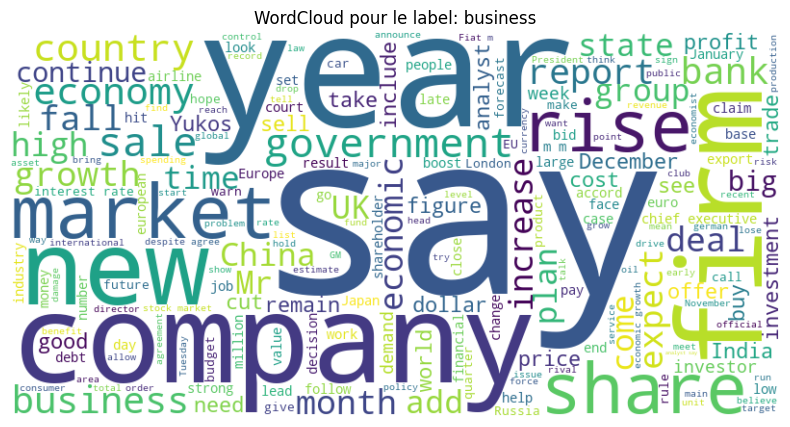

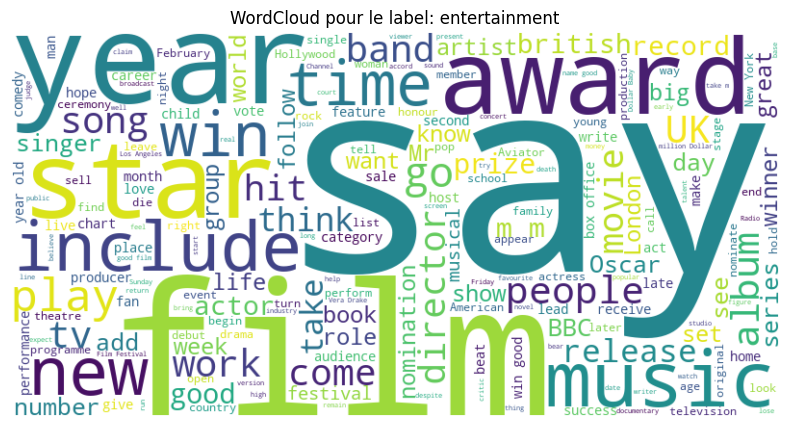

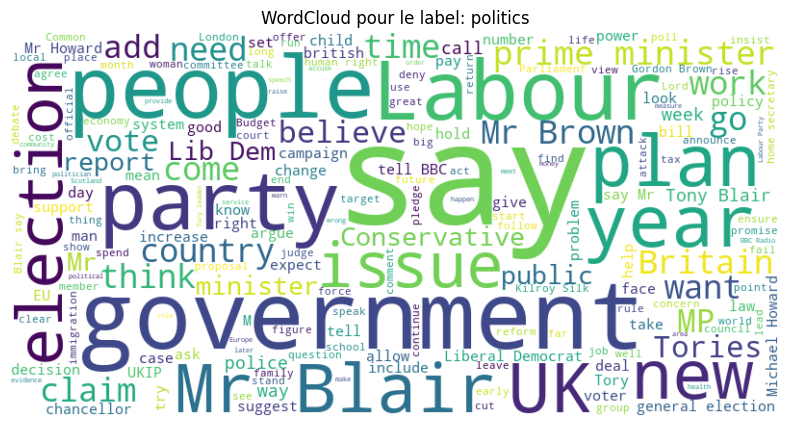

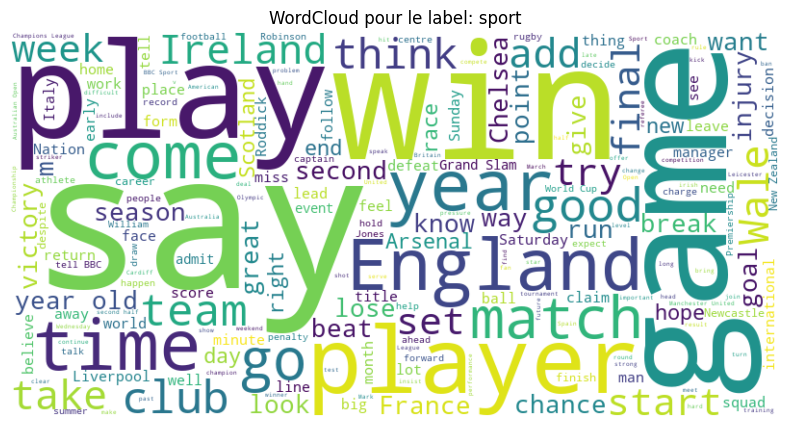

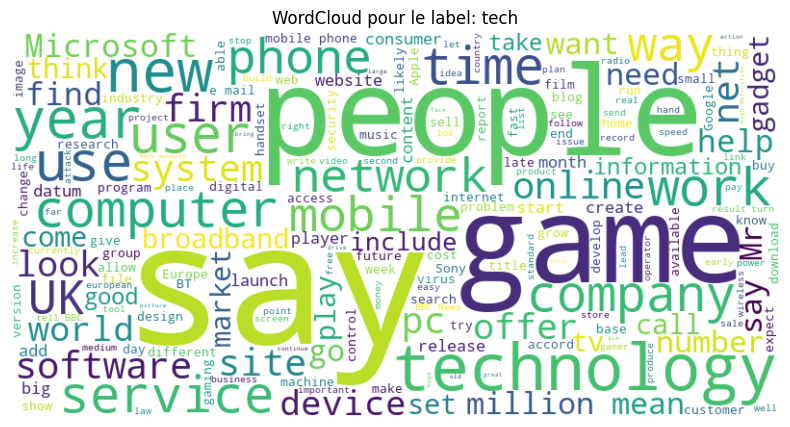

In [7]:
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Charger le modèle spaCy
nlp = spacy.load('en_core_web_sm')

# Nettoyage et lemmatisation
def preprocess_text(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return ' '.join(tokens)

data['processed_text'] = data['text'].apply(preprocess_text)

# Visualisation des mots fréquents par label
for label in data['labels'].unique():
    text = ' '.join(data[data['labels'] == label]['processed_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud pour le label: {label}')
    plt.show()

In [8]:
data['processed_text'].head()

0    ad sale boost Time Warner profit Quarterly pro...
1    dollar gain Greenspan speech dollar hit high l...
2    Yukos unit buyer face loan claim owner embattl...
3    high fuel price hit BA profit British Airways ...
4    pernod takeover talk lift domecq share UK drin...
Name: processed_text, dtype: object

#### Topic Modelling

In [9]:
from sklearn.decomposition import LatentDirichletAllocation

# Vectorisation
vectorizer = CountVectorizer(max_features=5000)
X = vectorizer.fit_transform(data['processed_text'])

# Modèle LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# Afficher les topics
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}:")
    print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]])

Topic 0:
['share', 'price', 'bank', 'firm', 'rise', 'sale', 'market', 'company', 'year', 'say']
Topic 1:
['director', 'take', 'include', 'star', 'win', 'award', 'say', 'year', 'good', 'film']
Topic 2:
['blair', 'plan', 'minister', 'election', 'party', 'labour', 'people', 'government', 'mr', 'say']
Topic 3:
['music', 'use', 'service', 'new', 'phone', 'technology', 'mobile', 'game', 'people', 'say']
Topic 4:
['club', 'good', 'england', 'player', 'time', 'year', 'game', 'play', 'win', 'say']


### Analyse de sentiment 

#### TextBlob

labels
business         0.059707
entertainment    0.146567
politics         0.068787
sport            0.112700
tech             0.103772
Name: sentiment, dtype: float64


C:\Users\ntouman\AppData\Local\Temp\ipykernel_7024\708640931.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='labels', y='sentiment', data=data, palette='Set2', linewidth=2.5)


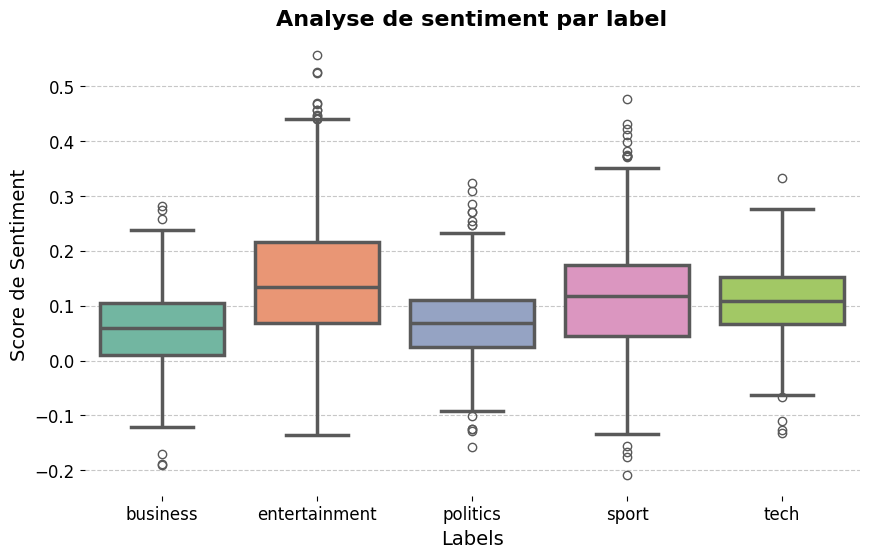

In [10]:
from textblob import TextBlob
import seaborn as sns
# Analyse de sentiment
data['sentiment'] = data['text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Moyenne des sentiments par label
print(data.groupby('labels')['sentiment'].mean())

# Visualisation améliorée
plt.figure(figsize=(10, 6))
sns.boxplot(x='labels', y='sentiment', data=data, palette='Set2', linewidth=2.5)
sns.despine(left=True, bottom=True)
plt.title('Analyse de sentiment par label', fontsize=16, fontweight='bold')
plt.xlabel('Labels', fontsize=14)
plt.ylabel('Score de Sentiment', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Nltk avec Vader

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ntouman\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


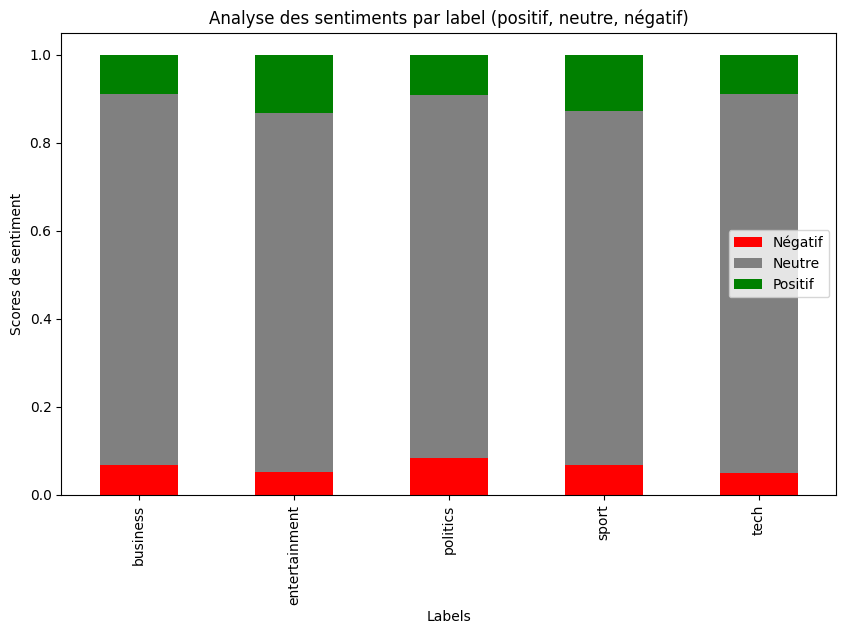

In [19]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer 
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

# Télécharger les ressources nécessaires pour VADER
nltk.download('vader_lexicon')

# Initialiser l'analyseur de sentiment
sia = SentimentIntensityAnalyzer()

# Appliquer l'analyse de sentiment
data['vader_sentiment'] = data['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

    # Calculer les moyennes des scores de sentiment (positif, neutre, négatif) par label
sentiment_scores_by_label = data['text'].apply(sia.polarity_scores).apply(pd.Series)
sentiment_scores_by_label['labels'] = data['labels']
sentiment_means = sentiment_scores_by_label.groupby('labels')[['neg', 'neu', 'pos']].mean()

# Visualisation des scores de sentiment par label
sentiment_means.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'gray', 'green'])
plt.title('Analyse des sentiments par label (positif, neutre, négatif)')
plt.xlabel('Labels')
plt.ylabel('Scores de sentiment')
plt.legend(['Négatif', 'Neutre', 'Positif'])
plt.show()

plt.show()

### Modélisation

### Prétraitement des données 

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorisation TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data['processed_text'])
y = data['labels']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Entraînement du modèle Random Forest
# Entraînement du modèle
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Évaluation sur l'ensemble d'entraînement
y_pred_train_rf = model.predict(X_train)
print("Random Forest Classification Report (Train):")
print(classification_report(y_train, y_pred_train_rf))

# Évaluation sur l'ensemble de test
y_pred_rf = model.predict(X_test)
print("Random Forest Classification Report (Test):")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report (Train):
               precision    recall  f1-score   support

     business       1.00      1.00      1.00       399
entertainment       1.00      1.00      1.00       291
     politics       1.00      1.00      1.00       330
        sport       1.00      1.00      1.00       407
         tech       1.00      1.00      1.00       274

     accuracy                           1.00      1701
    macro avg       1.00      1.00      1.00      1701
 weighted avg       1.00      1.00      1.00      1701

Random Forest Classification Report (Test):
               precision    recall  f1-score   support

     business       0.94      0.98      0.96       104
entertainment       0.99      0.92      0.95        78
     politics       0.99      0.97      0.98        73
        sport       0.97      1.00      0.98        98
         tech       0.99      0.97      0.98        73

     accuracy                           0.97       426
    macro avg       0.97  

#### Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

# Entraînement du modèle Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred_lr = lr_model.predict(X_test)

# Prédictions sur l'ensemble d'entraînement
y_pred_train_lr = lr_model.predict(X_train)

# Évaluation des métriques sur l'ensemble d'entraînement
print("Logistic Regression Classification Report (Train):")
print(classification_report(y_train, y_pred_train_lr))

# Évaluation des métriques sur l'ensemble de test
print("Logistic Regression Classification Report (Test):")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Classification Report (Train):
               precision    recall  f1-score   support

     business       0.99      0.99      0.99       399
entertainment       1.00      1.00      1.00       291
     politics       0.99      0.99      0.99       330
        sport       1.00      1.00      1.00       407
         tech       0.99      1.00      0.99       274

     accuracy                           0.99      1701
    macro avg       0.99      0.99      0.99      1701
 weighted avg       0.99      0.99      0.99      1701

Logistic Regression Classification Report (Test):
               precision    recall  f1-score   support

     business       0.99      0.97      0.98       104
entertainment       0.99      0.95      0.97        78
     politics       0.96      1.00      0.98        73
        sport       1.00      1.00      1.00        98
         tech       0.96      0.99      0.97        73

     accuracy                           0.98       426
    macro avg 

### Evaluation des modèles 

#### Métriques de performance

In [15]:
from sklearn.metrics import f1_score, accuracy_score, log_loss
import numpy as np

# F1-score
print("Random Forest F1-Score:", f1_score(y_test, y_pred_rf, average='weighted'))
print("Logistic Regression F1-Score:", f1_score(y_test, y_pred_lr, average='weighted'))

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# Perplexité (basée sur log_loss)
rf_log_loss = log_loss(y_test, model.predict_proba(X_test))
lr_log_loss = log_loss(y_test, lr_model.predict_proba(X_test))
print("Random Forest Perplexity:", np.exp(rf_log_loss))
print("Logistic Regression Perplexity:", np.exp(lr_log_loss))

Random Forest F1-Score: 0.9717406128369304
Logistic Regression F1-Score: 0.9811943457411682
Random Forest Accuracy: 0.971830985915493
Logistic Regression Accuracy: 0.9812206572769953
Random Forest Perplexity: 1.4953353332853432
Logistic Regression Perplexity: 1.4300747657197426


#### Matrice de confusion 

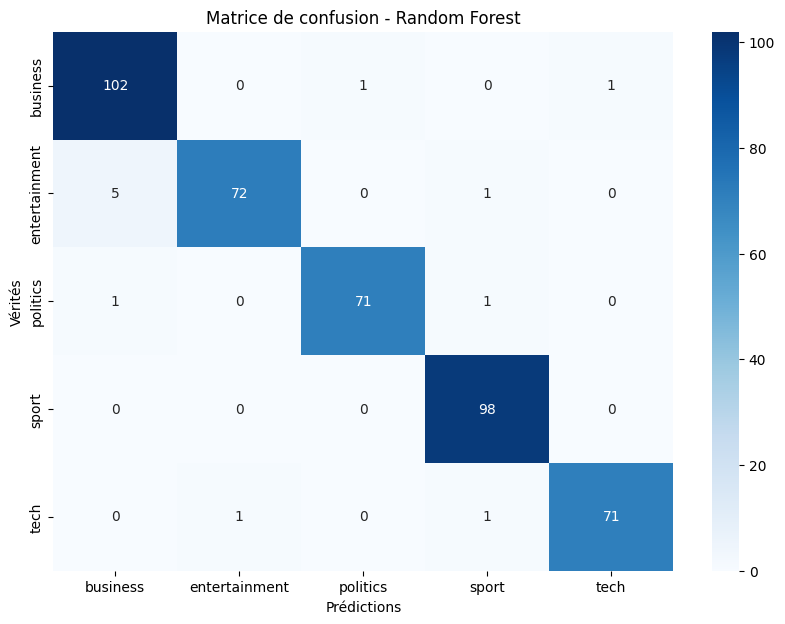

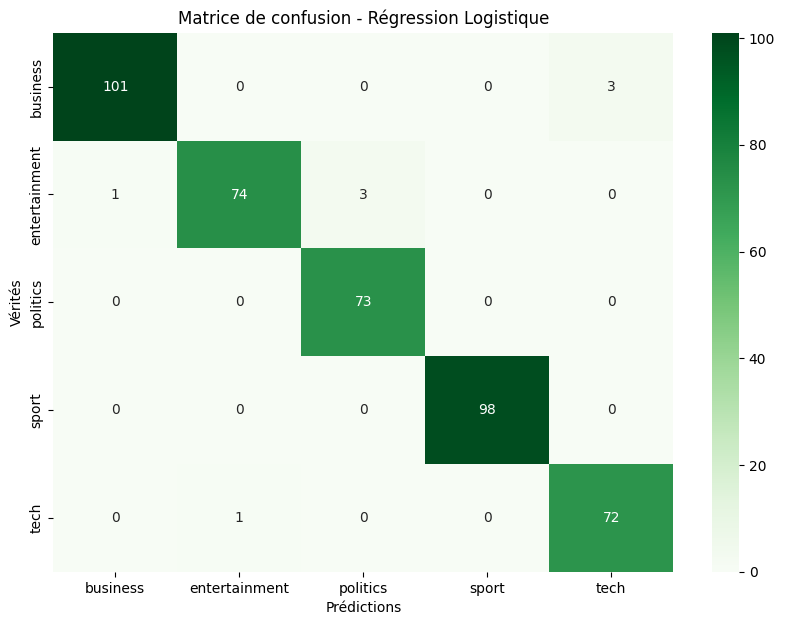

In [16]:
from sklearn.metrics import confusion_matrix

# Calcul des matrices de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=y.unique())
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=y.unique())

# Matrice de confusion pour Random Forest
cm_rf_df = pd.DataFrame(cm_rf, index=y.unique(), columns=y.unique())
cm_rf_df = cm_rf_df.fillna(0)  # Remplir les valeurs manquantes avec des zéros
plt.figure(figsize=(10, 7))
sns.heatmap(cm_rf_df, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()

# Matrice de confusion pour Régression Logistique
cm_lr_df = pd.DataFrame(cm_lr, index=y.unique(), columns=y.unique())
cm_lr_df = cm_lr_df.fillna(0)  # Remplir les valeurs manquantes avec des zéros
plt.figure(figsize=(10, 7))
sns.heatmap(cm_lr_df, annot=True, fmt='d', cmap='Greens')
plt.title("Matrice de confusion - Régression Logistique")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()


#### Importance des mots 

In [17]:
# Importance des mots pour Random Forest
feature_importances_rf = model.feature_importances_
top_indices_rf = np.argsort(feature_importances_rf)[-10:]

print("Top 10 mots importants pour Random Forest:")
print([tfidf.get_feature_names_out()[i] for i in top_indices_rf])

# Importance des mots pour Régression Logistique
coefficients_lr = lr_model.coef_.flatten()

# Obtenir les indices des 10 coefficients les plus importants (en valeur absolue)
top_indices_lr = np.argsort(np.abs(coefficients_lr))[-10:]

# Vérifier que les indices sont dans les limites du vocabulaire TF-IDF
top_indices_lr = [i for i in top_indices_lr if i < len(tfidf.get_feature_names_out())]

# Afficher les mots correspondants
print("\nTop 10 mots importants pour Logistic Regression:")
print([tfidf.get_feature_names_out()[i] for i in top_indices_lr])

Top 10 mots importants pour Random Forest:
['star', 'labour', 'mr', 'company', 'match', 'win', 'market', 'firm', 'government', 'film']

Top 10 mots importants pour Logistic Regression:
['company', 'firm']


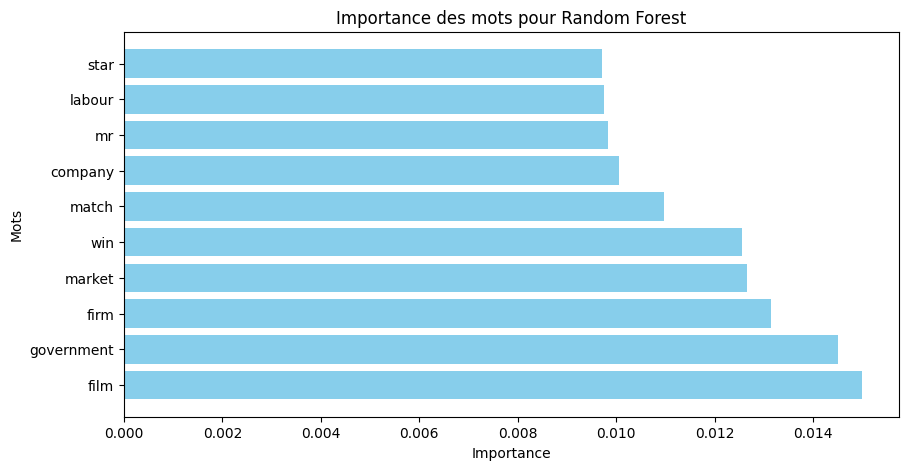

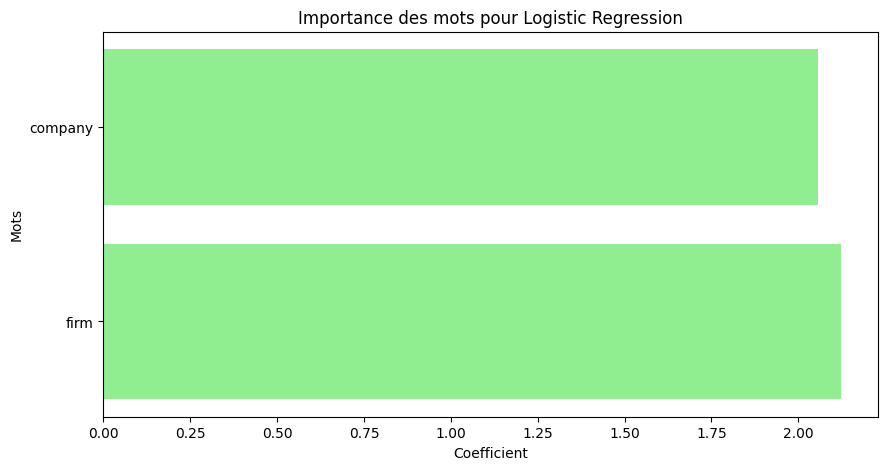

In [18]:
import numpy as np

import matplotlib.pyplot as plt

# Importance des mots pour Random Forest
top_words_rf = [tfidf.get_feature_names_out()[i] for i in top_indices_rf]
top_importances_rf = feature_importances_rf[top_indices_rf]

# Importance des mots pour Logistic Regression
top_words_lr = [tfidf.get_feature_names_out()[i] for i in top_indices_lr]
top_importances_lr = coefficients_lr[top_indices_lr]

# Visualisation pour Random Forest
plt.figure(figsize=(10, 5))
plt.barh(top_words_rf, top_importances_rf, color='skyblue')
plt.xlabel("Importance")
plt.ylabel("Mots")
plt.title("Importance des mots pour Random Forest")
plt.gca().invert_yaxis()
plt.show()

# Visualisation pour Logistic Regression
plt.figure(figsize=(10, 5))
plt.barh(top_words_lr, top_importances_lr, color='lightgreen')
plt.xlabel("Coefficient")
plt.ylabel("Mots")
plt.title("Importance des mots pour Logistic Regression")
plt.gca().invert_yaxis()
plt.show()